In [2]:
import pandas as pd
import numpy as np
from pyMyriad import *

In [3]:
df = pd.DataFrame({
  "id": np.arange(1000),
  "Gender": np.random.choice(["M", "F"], 1000),
  "Age": np.random.randint(18, 70, 1000),
  "Income": np.random.normal(50000, 15000, 1000),
  "Country": np.random.choice(["Benin", "Albania"], 1000),
  "Education": np.random.normal(0, 1, 1000),
  "Employed": np.random.choice([0, 1], 1000)
})

# Basic usage
The analysis tree is constructed by successive split and analyis adding nodes to the tree.
- `split_*` methods add split nodes, dividing or filtering the dataframe.
- `analyze_*` methods add an analysis node that and block further splitting at the node where it was added.
- `summarize_*` methods add an analysis node but won't block further splitting at the node where it was added.

Split and analysis can be specified either as sting of functions.
**Note: use `df` to refer to the dataframe available at the node.**

The resulting analyis tree can be printed to visualize the analysis plan

In [4]:
mfun = lambda df: np.mean(df.Income)
nfun = lambda df: np.std(df.Income)
efun = lambda df: np.mean(df.Education)
benin_fun =  lambda df: df.Country == 'Benin'
age_40 = lambda df: df.Age > 40
age_60 = lambda df: df.Age > 60

atree = AnalysisTree()\
  .split_by("df.Gender")\
  .summarize_by(m = mfun, n = nfun)\
  .split_by(label = "Benin Y/N", expr = benin_fun)\
  .split_by(label = "Age Group", age40 = age_40, age60 = age_60)\
  .analyze_by(m = mfun, n = nfun, label = "Income analysis")\
  .analyze_by(m = efun, label = "Education analysis")


print(atree)

Analysis Tree
  └- Split Node df.Gender: [df.Gender]
    └- Analysis Node: 
        m: <function>
        n: <function>
    └- Split Node Benin Y/N: [<function>]
      └- Split Node Age Group: [age40: <function> -- age60: <function>]
        └- Analysis Node: Income analysis
            m: <function>
            n: <function>
        └- Analysis Node: Education analysis
            m: <function>



The `run` method applies the analysis plan on a dataframe and returns a `DataTree`.

In [5]:
res = atree.run(df)
print(res)

Data Tree
  Split: df.Gender
    └- F
        analysis: 
        └- m: 48941.74143180219
        └- n: 14830.813018183255
      Split: Benin Y/N
        └- False
          Split: Age Group
            └- age40
                analysis: Income analysis
                └- m: 50310.17335875197
                └- n: 12543.302573827863
                analysis: Education analysis
                └- m: -0.1186382891938738
            └- age60
                analysis: Income analysis
                └- m: 50517.78628143656
                └- n: 12272.628710497838
                analysis: Education analysis
                └- m: -0.42921454816426646
        └- True
          Split: Age Group
            └- age40
                analysis: Income analysis
                └- m: 48781.44522028319
                └- n: 15643.465265032703
                analysis: Education analysis
                └- m: 0.08233250738282588
            └- age60
                analysis: Income analysis
           

# Plot

The `plot` method can be used to visualize the analysis tree as a forest plot.

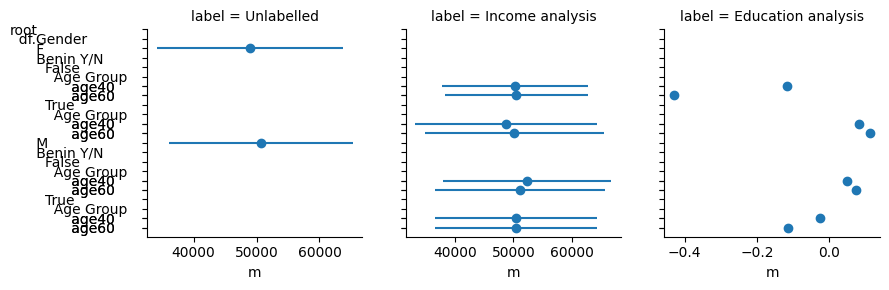

None

In [6]:
from pyMyriad.plots import forest_plot
import importlib
ff = forest_plot(res, "m", "n")
display(ff)

in forest plot, a split level can be respresented as a colour.

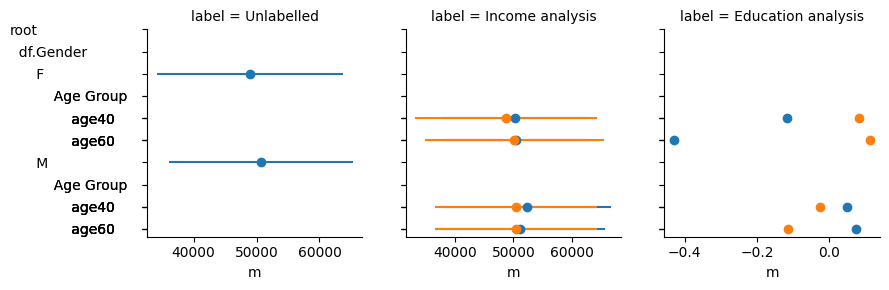

None

In [7]:
ff = forest_plot(res, "m", "n", col= "Benin Y/N")
display(ff)